<a href="https://colab.research.google.com/github/Captain-Rohith/DL-PRoject/blob/main/DL_23f3001358_notebook_t12026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

jan_2026_dl_gen_ai_project_path = kagglehub.competition_download('jan-2026-dl-gen-ai-project')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import librosa
import numpy as np
import soundfile as sf
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

TRAIN_DIR = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
print("Genres found:", sorted(os.listdir(TRAIN_DIR)))

CUDA available: True
GPU: Tesla T4
Genres found: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [ ]:
stem_files = []
for genre in sorted(os.listdir(TRAIN_DIR)):
    genre_path = os.path.join(TRAIN_DIR, genre)
    if not os.path.isdir(genre_path):
        continue
    for song in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song)
        if not os.path.isdir(song_path):
            continue
        for stem in ['drums.wav', 'vocals.wav', 'bass.wav', 'others.wav']:
            fpath = os.path.join(song_path, stem)
            if os.path.exists(fpath):
                stem_files.append({'genre': genre, 'song': song, 'stem': stem, 'path': fpath})

df = pd.DataFrame(stem_files)
print(f"Total stem files found: {len(df)}")
df.head()

Total stem files found: 3000


,genre,song,stem,path
0,blues,blues.00095,drums.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
1,blues,blues.00095,vocals.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
2,blues,blues.00095,bass.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
3,blues,blues.00006,drums.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
4,blues,blues.00006,vocals.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...


In [ ]:
def check_file(path):
    if os.path.getsize(path) == 0:
        return path, 'zero_byte'
    try:
        sf.info(path)
        return path, 'ok'
    except Exception as e:
        return path, f'corrupt: {e}'

corrupted = []
with ThreadPoolExecutor(max_workers=16) as executor:
    futures = {executor.submit(check_file, row['path']): row['path'] for _, row in df.iterrows()}
    for future in as_completed(futures):
        path, status = future.result()
        if status != 'ok':
            corrupted.append((path, status))

print(f"Corrupted or zero-byte files: {len(corrupted)}")
for p, s in corrupted[:10]:
    print(f"  {p} -> {s}")

Corrupted or zero-byte files: 0


In [ ]:
def get_meta(row):
    try:
        info = sf.info(row['path'])
        return {**row, 'duration': info.duration, 'samplerate': info.samplerate, 'error': None}
    except Exception as e:
        return {**row, 'duration': None, 'samplerate': None, 'error': str(e)}

rows = df.to_dict('records')
results = []
with ThreadPoolExecutor(max_workers=16) as executor:
    futures = [executor.submit(get_meta, r) for r in rows]
    for future in as_completed(futures):
        results.append(future.result())

meta_df = pd.DataFrame(results)
print(f"Loaded metadata for {len(meta_df)} files")
print(meta_df[['genre','stem','duration','samplerate']].head(10))

Loaded metadata for 3000 files
   genre        stem   duration  samplerate
0  blues  vocals.wav  30.013333       44100
1  blues    bass.wav  30.013333       44100
2  blues  vocals.wav  30.013333       44100
3  blues   drums.wav  30.013333       44100
4  blues  vocals.wav  30.013333       44100
5  blues    bass.wav  30.013333       44100
6  blues   drums.wav  30.013333       44100
7  blues   drums.wav  30.013333       44100
8  blues  vocals.wav  30.013333       44100
9  blues  vocals.wav  30.013333       44100


In [ ]:
jazz_df = meta_df[meta_df['genre'] == 'jazz']
mean_jazz_duration = jazz_df['duration'].mean()
print(f"Q1 - Mean duration of Jazz genre stems: {mean_jazz_duration:.4f} seconds")

Q1 - Mean duration of Jazz genre stems: 30.0330 seconds


In [ ]:
unique_sr = sorted(meta_df['samplerate'].dropna().unique().astype(int).tolist())
print(f"Q2 - Unique sample rates present: {unique_sr}")

Q2 - Unique sample rates present: [44100]


In [ ]:
import torch
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def process_audio(path, stem, genre, sr_target=22050):
    result = {
        'path': path, 'stem': stem, 'genre': genre,
        'peak_db': None, 'spectral_centroid': None, 'silence_first_half_sec': False
    }
    try:
        y, sr = librosa.load(path, sr=sr_target, mono=True)

        # Move to GPU tensor
        y_tensor = torch.tensor(y, dtype=torch.float32, device=device)

        # Peak amplitude in dB (GPU)
        peak = torch.max(torch.abs(y_tensor)).item()
        result['peak_db'] = 20 * np.log10(peak) if peak > 0 else -np.inf

        # Silence in first 0.5s (GPU)
        half_sec_samples = int(0.5 * sr_target)
        first_chunk = y_tensor[:half_sec_samples]
        result['silence_first_half_sec'] = (torch.max(torch.abs(first_chunk)).item() < 0.01)

        # Spectral centroid (CPU via librosa — no GPU equivalent in librosa)
        sc = librosa.feature.spectral_centroid(y=y, sr=sr)
        result['spectral_centroid'] = float(np.mean(sc))

    except Exception as e:
        result['error'] = str(e)

    return result

# Run in parallel threads (GPU ops are fast per file; threading handles I/O overlap)
valid_rows = meta_df[meta_df['duration'].notna()].to_dict('records')

audio_results = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [
        executor.submit(process_audio, r['path'], r['stem'], r['genre'])
        for r in valid_rows
    ]
    for i, future in enumerate(as_completed(futures)):
        audio_results.append(future.result())
        if (i + 1) % 500 == 0:
            print(f"  Processed {i+1}/{len(valid_rows)} files...")

audio_df = pd.DataFrame(audio_results)
print(f"\nDone. Processed {len(audio_df)} files.")
audio_df.head()

Using device: cuda
  Processed 500/3000 files...
  Processed 1000/3000 files...
  Processed 1500/3000 files...
  Processed 2000/3000 files...
  Processed 2500/3000 files...
  Processed 3000/3000 files...

Done. Processed 3000 files.


,path,stem,genre,peak_db,spectral_centroid,silence_first_half_sec
0,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,drums.wav,blues,-18.756686,3528.703861,True
1,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,vocals.wav,blues,-0.315275,3480.629747,True
2,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,bass.wav,blues,-4.095715,134.854067,False
3,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,bass.wav,blues,-6.966076,116.991759,False
4,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,vocals.wav,blues,-3.386444,1765.145963,False


In [ ]:
vocal_peaks = audio_df[
    (audio_df['stem'] == 'vocals.wav') &
    (audio_df['peak_db'].notna()) &
    (audio_df['peak_db'] != -np.inf)
]['peak_db']

avg_peak_db = vocal_peaks.mean()
print(f"Q4 - Average peak amplitude for vocal stems: {avg_peak_db:.4f} dB")

Q4 - Average peak amplitude for vocal stems: -12.6078 dB


In [ ]:
sc_df = (
    audio_df.groupby('genre')['spectral_centroid']
    .mean()
    .reset_index()
    .rename(columns={'spectral_centroid': 'mean_spectral_centroid'})
    .sort_values('mean_spectral_centroid', ascending=False)
)

print("Mean Spectral Centroid by Genre:")
print(sc_df.to_string(index=False))

blues_sc = sc_df[sc_df['genre'] == 'blues']['mean_spectral_centroid'].values[0]
top_genre = sc_df.iloc[0]

print(f"\nQ5 - Mean spectral centroid for Blues: {blues_sc:.4f} Hz")
print(f"Q6 - Genre with highest mean spectral centroid: {top_genre['genre']} ({top_genre['mean_spectral_centroid']:.4f} Hz)")

Mean Spectral Centroid by Genre:
    genre  mean_spectral_centroid
      pop             2637.650640
    disco             2552.219936
    metal             2524.667227
     jazz             2507.647414
   reggae             2426.699061
     rock             2352.079148
  country             2347.090160
    blues             2224.128131
   hiphop             2185.056469
classical             1428.396315

Q5 - Mean spectral centroid for Blues: 2224.1281 Hz
Q6 - Genre with highest mean spectral centroid: pop (2637.6506 Hz)


In [ ]:
silence_count = audio_df['silence_first_half_sec'].sum()
print(f"Q7 - Stem files with silence in first 0.5 seconds: {silence_count}")

Q7 - Stem files with silence in first 0.5 seconds: 749


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]:
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Feature Extraction ---
print("Extracting training features...")
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre'].values

print("Extracting validation features...")
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre'].values

# --- 4. Model Training ---
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# --- 5. YOUR CODE HERE: Predictions and Metrics ---
y_pred = clf.predict(X_val)
macro_f1 = f1_score(y_val, y_pred, average='macro')
cm = confusion_matrix(y_val, y_pred, labels=GENRES)
cr = classification_report(y_val, y_pred, target_names=GENRES)
accuracy = accuracy_score(y_val, y_pred)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print(f"Model Accuracy: {accuracy:.4f}\n")
print("Detailed Classification Report:")
print(cr)

Extracting training features...
Extracting validation features...
Validation Macro F1 Score: 0.1523

Model Accuracy: 0.1900

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



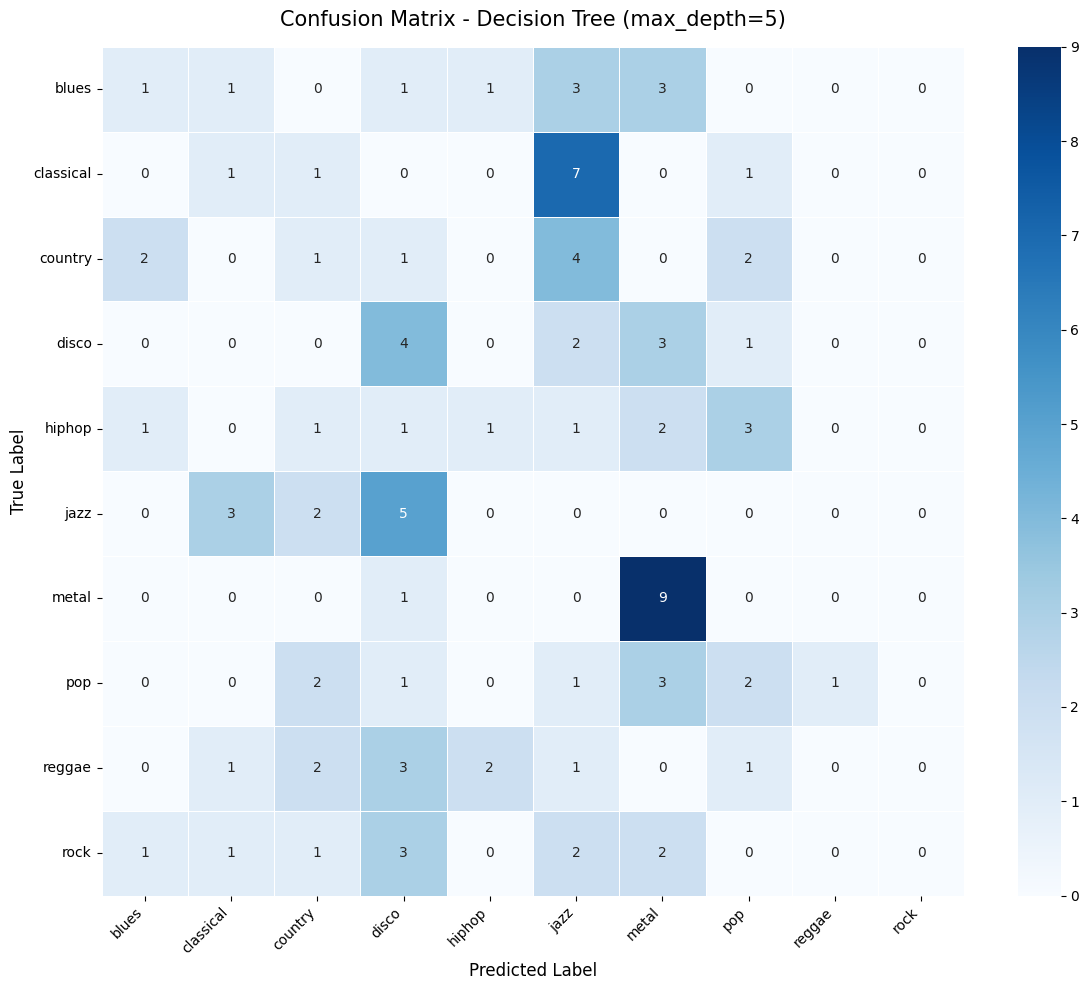

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=GENRES,
    yticklabels=GENRES,
    linewidths=0.5
)
plt.title('Confusion Matrix - Decision Tree (max_depth=5)', fontsize=15, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
tp_tn_fp_fn = []

for i, genre in enumerate(GENRES):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP      # predicted as genre but wrong
    FN = cm[i, :].sum() - TP      # actually genre but predicted wrong
    TN = cm.sum() - TP - FP - FN  # everything else correct

    tp_tn_fp_fn.append({
        'Genre': genre,
        'TP': TP,
        'TN': TN,
        'FP': FP,
        'FN': FN
    })

stats_df = pd.DataFrame(tp_tn_fp_fn).set_index('Genre')
print("=" * 55)
print(f"{'Genre':<12} {'TP':>6} {'TN':>6} {'FP':>6} {'FN':>6}")
print("=" * 55)
for genre, row in stats_df.iterrows():
    print(f"{genre:<12} {int(row['TP']):>6} {int(row['TN']):>6} {int(row['FP']):>6} {int(row['FN']):>6}")
print("=" * 55)

highest_tp = stats_df['TP'].idxmax()
lowest_fn  = stats_df['FN'].idxmin()
print(f"\nGenre with HIGHEST True Positives : {highest_tp} (TP={stats_df.loc[highest_tp,'TP']})")
print(f"Genre with LOWEST  False Negatives: {lowest_fn}  (FN={stats_df.loc[lowest_fn,'FN']})")

Genre            TP     TN     FP     FN
blues             1     86      4      9
classical         1     84      6      9
country           1     81      9      9
disco             4     74     16      6
hiphop            1     87      3      9
jazz              0     69     21     10
metal             9     77     13      1
pop               2     82      8      8
reggae            0     89      1     10
rock              0     90      0     10

Genre with HIGHEST True Positives : metal (TP=9)
Genre with LOWEST  False Negatives: metal  (FN=1)


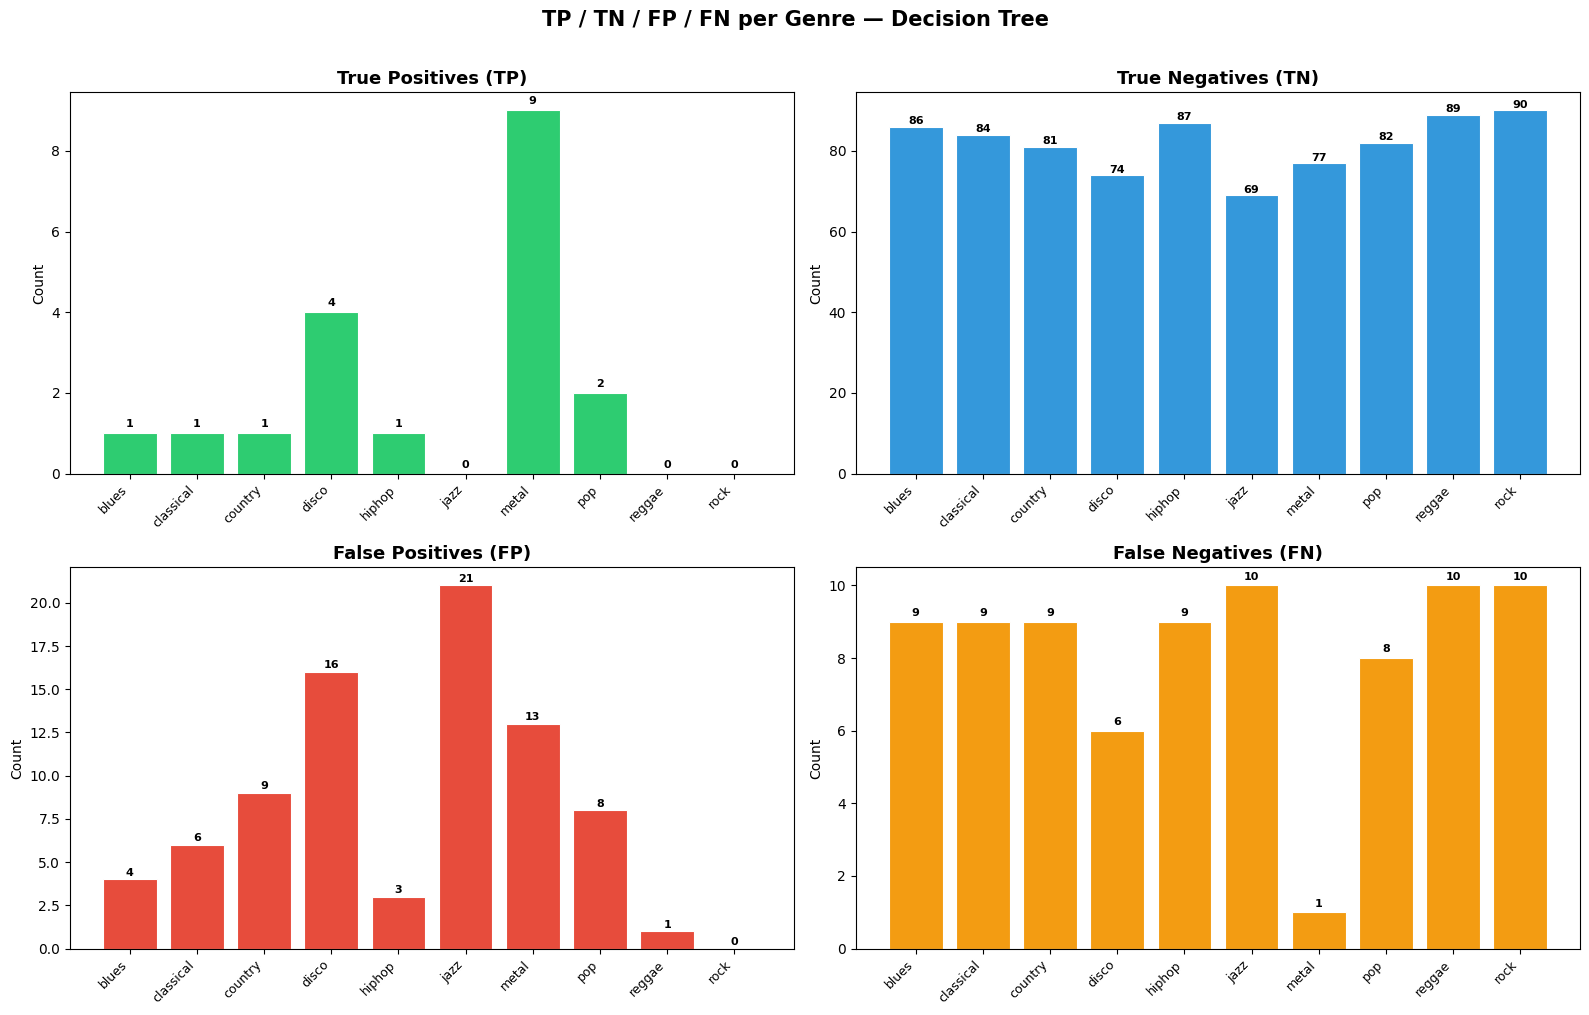

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['TP', 'TN', 'FP', 'FN']
colors  = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
titles  = ['True Positives (TP)', 'True Negatives (TN)', 'False Positives (FP)', 'False Negatives (FN)']

for ax, metric, color, title in zip(axes.flat, metrics, colors, titles):
    vals = stats_df[metric].astype(int)
    bars = ax.bar(stats_df.index, vals, color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticks(range(len(GENRES)))
    ax.set_xticklabels(GENRES, rotation=45, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('TP / TN / FP / FN per Genre — Decision Tree', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()